<h2>Importing Packages and Data</h2>

In [64]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [189]:
# seasons = range(2006, 2024)     #Passing stats started in 2006
pbp_py = nfl.import_pbp_data([2023])
pbp_py_2016 = nfl.import_pbp_data([2016])

2023 done.
Downcasting floats.
2016 done.
Downcasting floats.


<h2>Simple Model</h2>
<p>Uses just offense and defense formation and identifies the ones that give the lowest EPA and reproduces that</p>

In [49]:
"""
Creating a predicitve model to classify the best defensive formation to be in based on the offensive formation and current game circumstances.
"""

#Create dataframe with only needed columns
game_situation = ["yardline_100", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive", "qtr", "down", "ydstogo", "play_type"] 
offensive = ["offense_formation", "offense_personnel"]
defensive = ["defenders_in_box", "defense_personnel", "number_of_pass_rushers", "defense_man_zone_type", "defense_coverage_type"]
epa = ["epa"]
df = pbp_py[game_situation + offensive + defensive + epa]
df[:15]

len(df)

49665

In [ ]:
#Cleaning the dataset of rows with NaNs (special teams plays, etc.)
df = df.dropna(subset=["yardline_100", "offense_formation"]).reset_index(drop=True)
len(df)

32201

In [ ]:
#Picks the "best defense" given the lowest average EPA per offensive/defensive grouping
epa_summary = (
    df.groupby(["offense_formation", "defense_personnel"])
      .epa.mean()
      .reset_index()
)

best_defense = (
    epa_summary.loc[epa_summary.groupby("offense_formation")["epa"].idxmin()]
    .rename(columns={"defense_personnel": "best_defense"})
)

df = df.merge(best_defense[["offense_formation", "best_defense"]], on="offense_formation")

,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,qtr,down,ydstogo,play_type,offense_formation,offense_personnel,defenders_in_box,defense_personnel,number_of_pass_rushers,defense_man_zone_type,defense_coverage_type,epa,best_defense
0,75.0,900.0,1800.0,3600.0,1.0,1.0,1.0,10.0,run,SHOTGUN,"1 RB, 2 TE, 2 WR",7.0,"3 DL, 4 LB, 4 DB",NaN,None,None,-0.336103,"5 DL, 0 LB, 6 DB"
1,72.0,870.0,1770.0,3570.0,1.0,1.0,2.0,7.0,pass,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",4.0,ZONE_COVERAGE,COVER_3,0.703308,"5 DL, 0 LB, 6 DB"
2,66.0,835.0,1735.0,3535.0,1.0,1.0,3.0,1.0,run,I_FORM,"1 RB, 1 TE, 3 WR",6.0,"2 DL, 4 LB, 5 DB",NaN,None,None,0.469799,"2 DL, 3 LB, 6 DB"
3,64.0,796.0,1696.0,3496.0,1.0,1.0,1.0,10.0,pass,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",4.0,ZONE_COVERAGE,COVER_4,-0.521544,"5 DL, 0 LB, 6 DB"
4,64.0,792.0,1692.0,3492.0,1.0,1.0,2.0,10.0,pass,SINGLEBACK,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",4.0,ZONE_COVERAGE,COVER_4,1.173154,"6 DL, 4 LB, 1 DB"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32196,37.0,168.0,168.0,168.0,26.0,5.0,2.0,6.0,pass,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"3 DL, 3 LB, 5 DB",4.0,MAN_COVERAGE,COVER_1,0.552538,"5 DL, 0 LB, 6 DB"
32197,32.0,127.0,127.0,127.0,26.0,5.0,3.0,1.0,run,SHOTGUN,"1 RB, 2 TE, 2 WR",5.0,"4 DL, 2 LB, 5 DB",4.0,None,None,1.728891,"5 DL, 0 LB, 6 DB"
32198,13.0,86.0,86.0,86.0,26.0,5.0,1.0,10.0,run,SHOTGUN,"1 RB, 3 TE, 1 WR",6.0,"4 DL, 2 LB, 5 DB",NaN,None,None,-0.330699,"5 DL, 0 LB, 6 DB"
32199,10.0,50.0,50.0,50.0,26.0,5.0,2.0,7.0,pass,SHOTGUN,"1 RB, 1 TE, 3 WR",6.0,"4 DL, 2 LB, 5 DB",4.0,ZONE_COVERAGE,COVER_4,-0.637115,"5 DL, 0 LB, 6 DB"


In [ ]:
#Training and predicting with model
X = pd.get_dummies(df[["offense_formation", "defense_personnel"]])
y = df["best_defense"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

0 DL, 6 LB, 5 DB       1.00      1.00      1.00       539
2 DL, 3 LB, 6 DB       1.00      1.00      1.00       305
3 DL, 2 LB, 5 DB       1.00      1.00      1.00       398
5 DL, 0 LB, 6 DB       1.00      1.00      1.00      3742
5 DL, 1 LB, 5 DB       1.00      1.00      1.00        90
6 DL, 4 LB, 1 DB       1.00      1.00      1.00      1367

        accuracy                           1.00      6441
       macro avg       1.00      1.00      1.00      6441
    weighted avg       1.00      1.00      1.00      6441



In [ ]:
#Testing model with synthetic data
new_play = pd.DataFrame({
    "offense_formation": ["SHOTGUN"],
    "defense_personnel": ["3 DL, 2 LB, 6 DB"]
})
new_play_encoded = pd.get_dummies(new_play)

# Match columns to training data
new_play_encoded = new_play_encoded.reindex(columns=X.columns, fill_value=0)

predicted_best_defense = model.predict(new_play_encoded)
print(predicted_best_defense)

['5 DL, 0 LB, 6 DB']


<h2>Updated Model</h2>

In [124]:
features = game_situation + offensive + ["defense_personnel"]
target = "defense_personnel"

#Drop rows that do not have an offensive formation
df = pbp_py[features].dropna(subset=["yardline_100", "offense_formation"]).reset_index(drop=True)

# Remove the defense_personnel that occur only once
defense_counts = df['defense_personnel'].value_counts()
unique_defense_personnel = defense_counts[defense_counts < 10].index
df = df[~df['defense_personnel'].isin(unique_defense_personnel)].reset_index(drop=True)

# df.groupby(target).count()

In [125]:
X = pd.get_dummies(df[features])
y = df[target]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

# # Check if y_test contains unseen labels
# try:
#     y_test_encoded = le.transform(y_test)
# except ValueError as e:
#     print(f"Unseen labels in y_test: {e}")

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.8, random_state=42, stratify=y_enc)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                  precision    recall  f1-score   support

0 DL, 4 LB, 7 DB       1.00      1.00      1.00        57
0 DL, 5 LB, 6 DB       1.00      1.00      1.00        94
1 DL, 3 LB, 7 DB       1.00      0.94      0.97        18
1 DL, 4 LB, 6 DB       1.00      1.00      1.00       220
1 DL, 5 LB, 5 DB       1.00      1.00      1.00       188
2 DL, 2 LB, 7 DB       1.00      0.94      0.97        16
2 DL, 3 LB, 6 DB       1.00      1.00      1.00       981
2 DL, 4 LB, 5 DB       1.00      1.00      1.00      4881
2 DL, 5 LB, 4 DB       1.00      1.00      1.00        42
3 DL, 1 LB, 7 DB       1.00      1.00      1.00        79
3 DL, 2 LB, 6 DB       1.00      1.00      1.00       937
3 DL, 3 LB, 5 DB       1.00      1.00      1.00      4755
3 DL, 4 LB, 4 DB       1.00      1.00      1.00      2631
3 DL, 5 LB, 3 DB       1.00      0.75      0.86         8
4 DL, 1 LB, 6 DB       1.00      1.00      1.00       643
4 DL, 2 LB, 5 DB       1.00      1.00      1.00      7020
4 DL, 3 LB, 4

In [ ]:
# from sklearn.metrics import accuracy_score
# y_train_pred = model.predict(X_train)
# print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

# from sklearn.model_selection import cross_val_score

# cv_scores = cross_val_score(model, X, y_enc, cv=5)
# print(f"Cross-validation accuracy scores: {cv_scores}")
# print(f"Average cross-validation score: {cv_scores.mean()}")

# from sklearn.metrics import confusion_matrix, classification_report

# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred, target_names=le.classes_))

Training Accuracy: 1.0


<h2>New Model</h2>

In [162]:
game_situation = ["yardline_100", "game_seconds_remaining", "qtr", "down", "ydstogo"] 
offensive = ["offense_formation", "offense_personnel"]

features = game_situation + offensive + ["defense_personnel"]
target = "defense_personnel"

#Drop rows that do not have an offensive formation
df = pbp_py[features].dropna(subset=["yardline_100", "offense_formation", "defense_personnel"]).reset_index(drop=True)

# Remove the defense_personnel that occur only once
defense_counts = df['defense_personnel'].value_counts()
unique_defense_personnel = defense_counts[defense_counts < 10].index
df = df[~df['defense_personnel'].isin(unique_defense_personnel)].reset_index(drop=True)

# df.groupby(target).count()
len(df)

32134

In [163]:
X = pd.get_dummies(df[features])
y = df[target]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

model = RandomForestClassifier(random_state=42, max_depth=10, min_samples_split=10, max_features='sqrt')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                  precision    recall  f1-score   support

0 DL, 4 LB, 7 DB       1.00      0.29      0.44        14
0 DL, 5 LB, 6 DB       1.00      0.88      0.93        24
1 DL, 3 LB, 7 DB       0.00      0.00      0.00         4
1 DL, 4 LB, 6 DB       1.00      1.00      1.00        55
1 DL, 5 LB, 5 DB       1.00      1.00      1.00        47
2 DL, 2 LB, 7 DB       0.00      0.00      0.00         4
2 DL, 3 LB, 6 DB       1.00      1.00      1.00       245
2 DL, 4 LB, 5 DB       1.00      1.00      1.00      1220
2 DL, 5 LB, 4 DB       1.00      1.00      1.00        10
3 DL, 1 LB, 7 DB       1.00      0.75      0.86        20
3 DL, 2 LB, 6 DB       1.00      1.00      1.00       234
3 DL, 3 LB, 5 DB       0.98      1.00      0.99      1189
3 DL, 4 LB, 4 DB       0.98      1.00      0.99       658
3 DL, 5 LB, 3 DB       0.00      0.00      0.00         2
4 DL, 1 LB, 6 DB       1.00      1.00      1.00       161
4 DL, 2 LB, 5 DB       0.99      1.00      1.00      1755
4 DL, 3 LB, 4

c:\Users\abons\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abons\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\abons\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [165]:
from sklearn.model_selection import cross_val_score

# Use cross-validation to estimate performance
cv_scores = cross_val_score(model, X, y_enc, cv=5)
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Average cross-validation score: {cv_scores.mean()}")


Cross-validation accuracy scores: [0.99081998 0.99299829 0.99066438 0.9926871  0.9929972 ]
Average cross-validation score: 0.9920333902971489


Current thoughts: 
- Analytics play a bigger part in football than we already thought. Our model is so accurate because they use a tool similar (though more complex) than this to chose what defensive formations to come out in.
- There's little variance when picking a defensive formation based on the offensive formation/circumstances. One typically points to the other and the coaches are very knowledgable about good formation match ups.

- Would this stay the same if predicting plays from 20 years ago?
- What if we remove offensive formation and base it just on the current circumstance?

<h2>Exploratory Data Analysis</h2>

In [172]:
# Assuming 'offense_formation' and 'defense_formation' are columns in your DataFrame
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['offense_formation'], df['defense_personnel'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Cramér's V calculation
n = contingency_table.sum().sum()  # total number of observations
cramer_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"Cramér's V: {cramer_v}")

Cramér's V: 0.24441295429124504


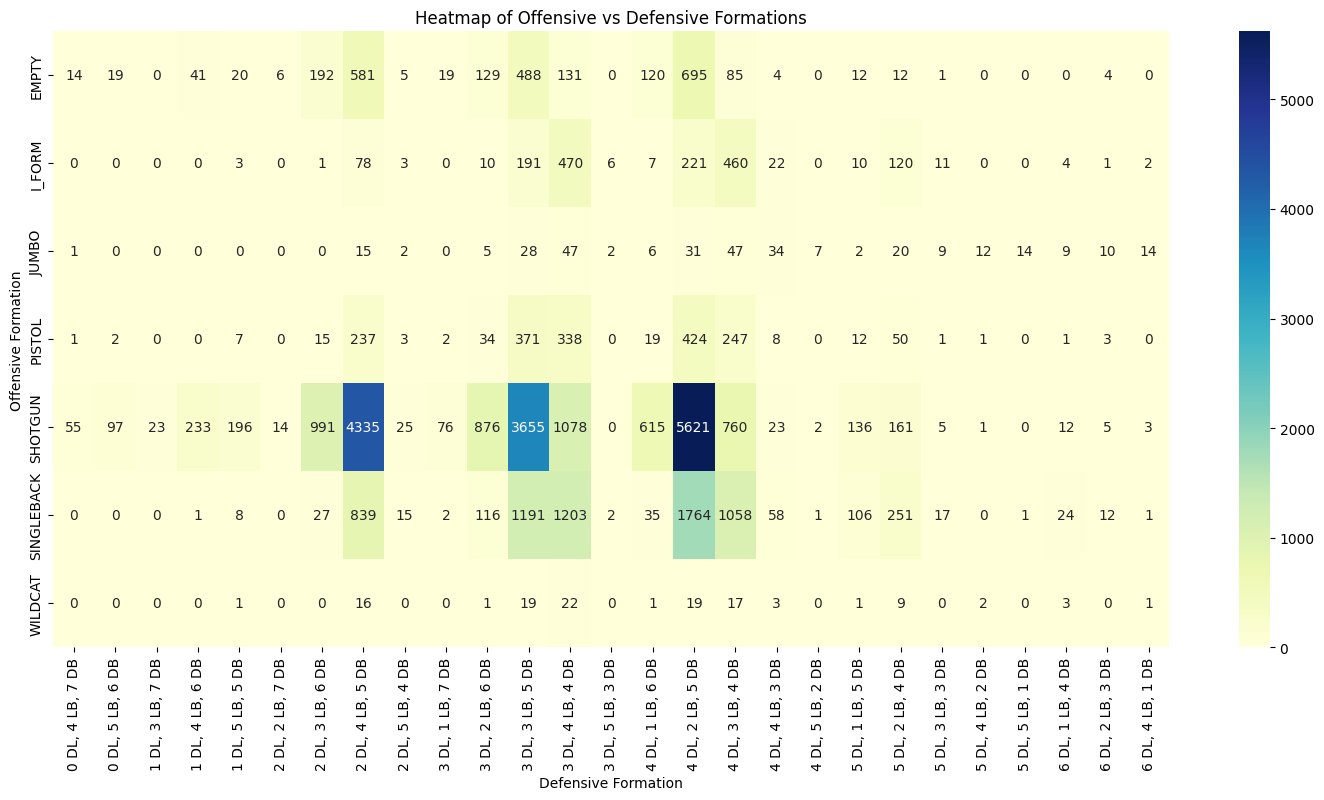

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a contingency table
contingency_table = pd.crosstab(df['offense_formation'], df['defense_personnel'])

# Create a heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(contingency_table, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Heatmap of Offensive vs Defensive Formations in 2023")
plt.xlabel('Defensive Formation')
plt.ylabel('Offensive Formation')
plt.show()

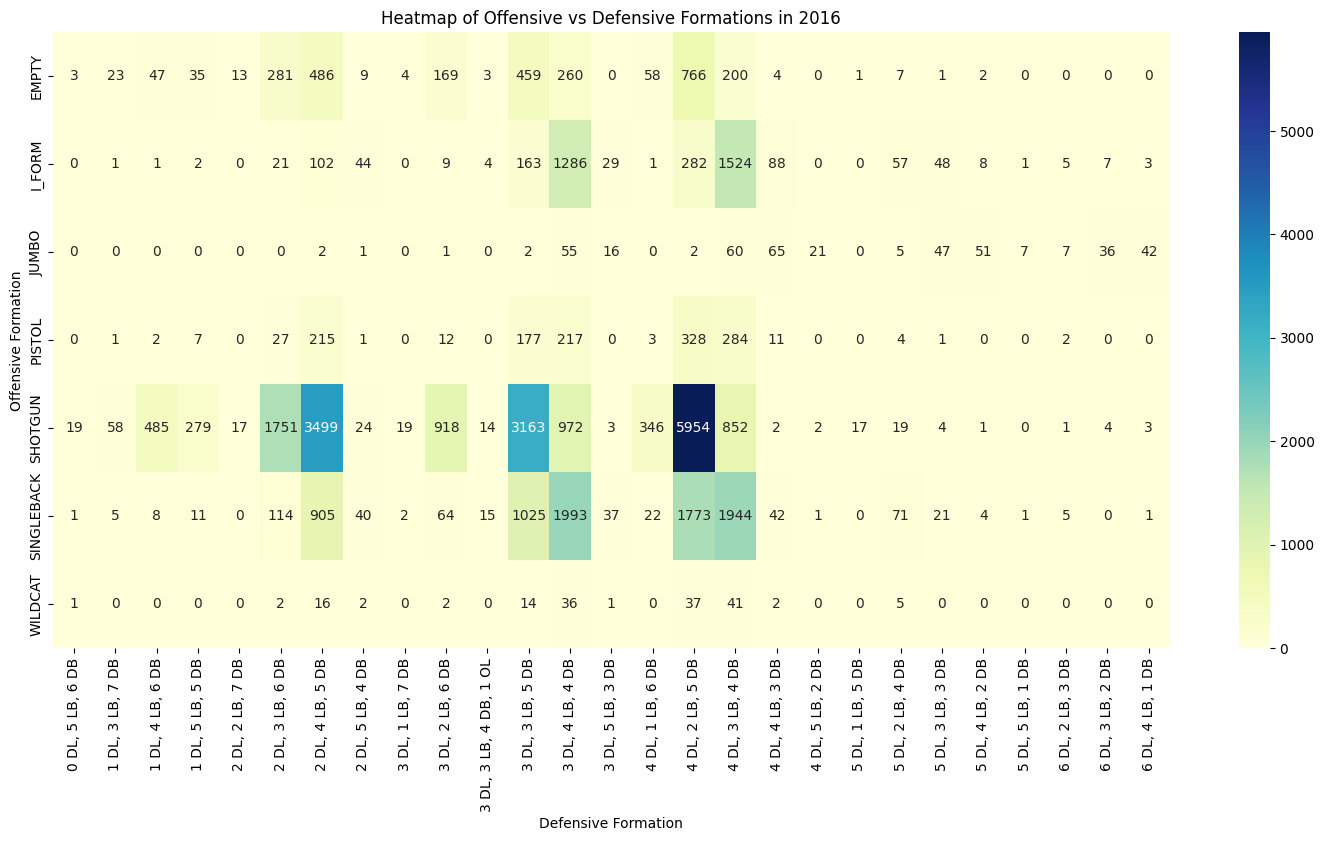

In [190]:
defense_counts = pbp_py_2016['defense_personnel'].value_counts()
unique_defense_personnel = defense_counts[defense_counts < 10].index
pbp_py_2016_r = pbp_py_2016[~pbp_py_2016['defense_personnel'].isin(unique_defense_personnel)].reset_index(drop=True)

# Create a contingency table
contingency_table = pd.crosstab(pbp_py_2016_r['offense_formation'], pbp_py_2016_r['defense_personnel'])

# Create a heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(contingency_table, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Heatmap of Offensive vs Defensive Formations in 2016")
plt.xlabel('Defensive Formation')
plt.ylabel('Offensive Formation')
plt.show()

Accuracy/precision is so high because there's basically 3 given defenses that will be chosen based on the offensive formation